# Simple text classification using ```scikit-learn```

## Import packages


In [1]:
# system tools
import os

# data marwling tools
import pandas as pd

# Machine learning stuff
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, ShuffleSplit
from sklearn import metrics

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

## Reading in the data

Our data is already in a tabular format, so we're going to load it using ```hf``` & ```pandas```

In [3]:
from utils import load_and_concat

In [4]:
df = load_and_concat("cornell-movie-review-data/rotten_tomatoes")
df.head()

README.md: 0.00B [00:00, ?B/s]

train.parquet:   0%|          | 0.00/699k [00:00<?, ?B/s]

validation.parquet:   0%|          | 0.00/90.0k [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/92.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Keys: dict_keys(['train', 'validation', 'test'])
Final len: 10662


,text,label
0,the rock is destined to be the 21st century's ...,1
1,"the gorgeously elaborate continuation of "" the...",1
2,effective but too-tepid biopic,1
3,if you sometimes like to go to the movies to h...,1
4,"emerges as something rare , an issue movie tha...",1


__Inspect data__

In [5]:
df.sample(10)

,text,label
2232,while insomnia is in many ways a conventional ...,1
1045,uses sharp humor and insight into human nature...,1
3387,poignant japanese epic about adolescent anomie...,1
5616,"just another disjointed , fairly predictable p...",0
2505,". . . a light , yet engrossing piece . lux , n...",1
501,the film will appeal to discovery channel fans...,1
5511,"granddad of le nouvelle vague , jean-luc godar...",0
7846,one of those decades-spanning historical epics...,0
5166,my own minority report is that it stinks .,0
7675,femme fatale offers nothing more than a bait-a...,0


In [7]:
df.shape

(10662, 2)

<br>
Q: How many examples of each label do we have?

In [8]:
df["label"].value_counts()

label
1    5331
0    5331
Name: count, dtype: int64

In [9]:
# let's make the labels text
df["label"] = df["label"].map({0: "negative", 1: "positive"})
df['label'].value_counts()

label
positive    5331
negative    5331
Name: count, dtype: int64

<br>

Let's now create new variables called ```X``` and ```y```, taking the data out of the dataframe so that we can mess around with them.

In [10]:
X = df["text"]
y = df["label"]

## Train-test split

I've included most of the 'hard work' for you here already, because these are long cells which might be easy to mess up while live-coding.

Instead, we'll discuss what's happening. If you have questions, don't be shy!

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,           # texts for the model
                                                    y,          # classification labels
                                                    test_size=0.2,   # create an 80/20 split
                                                    random_state=42) # random state for reproducibility

print(f"TRAIN set size: {len(X_train)}")
print(f"TEST set size: {len(X_test)}")
print("----")
print(f"TRAIN set class distribution:\n{y_train.value_counts()}")
print(f"TEST set class distribution:\n{y_test.value_counts()}")

TRAIN set size: 8529
TEST set size: 2133
----
TRAIN set class distribution:
label
positive    4286
negative    4243
Name: count, dtype: int64
TEST set class distribution:
label
negative    1088
positive    1045
Name: count, dtype: int64


## Vectorizing and Feature Extraction

Vectorization. What is it and why are all the cool kids talking about it?

Essentially, vectorization is the process whereby textual or visual data is 'transformed' into some kind of numerical representation. One of the easiest ways to do this is to simple count how often individual features appear in a document.

Take the following text: 
<br><br>
<i>My father’s family name being Pirrip, and my Christian name Philip, my infant tongue could make of both names nothing longer or more explicit than Pip. So, I called myself Pip, and came to be called Pip.</i>
<br>

We can convert this into the following vector

| and | be | being | both | called | came | christian | could | explicit | family | father | i | infant | longer | make | more | my | myself | name | names | nothing | of | or | philip | pip | pirrip | s | so | than | to | tongue|
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |  --- |
| 2 | 1 | 1 | 1 | 2 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 3 | 1 | 2 | 1 | 1 | 1 | 1 | 1 | 3 | 1 | 1 | 1 | 1 | 1 | 1 |

<br>
Our textual data is hence reduced to a jumbled-up 'vector' of numbers, known somewhat quaintly as a <i>bag-of-words</i>.
<br>
<br>
To do this in practice, we first need to create a vectorizer. 

Tfidf vectors tend to be better for training classifiers. Why might that be?

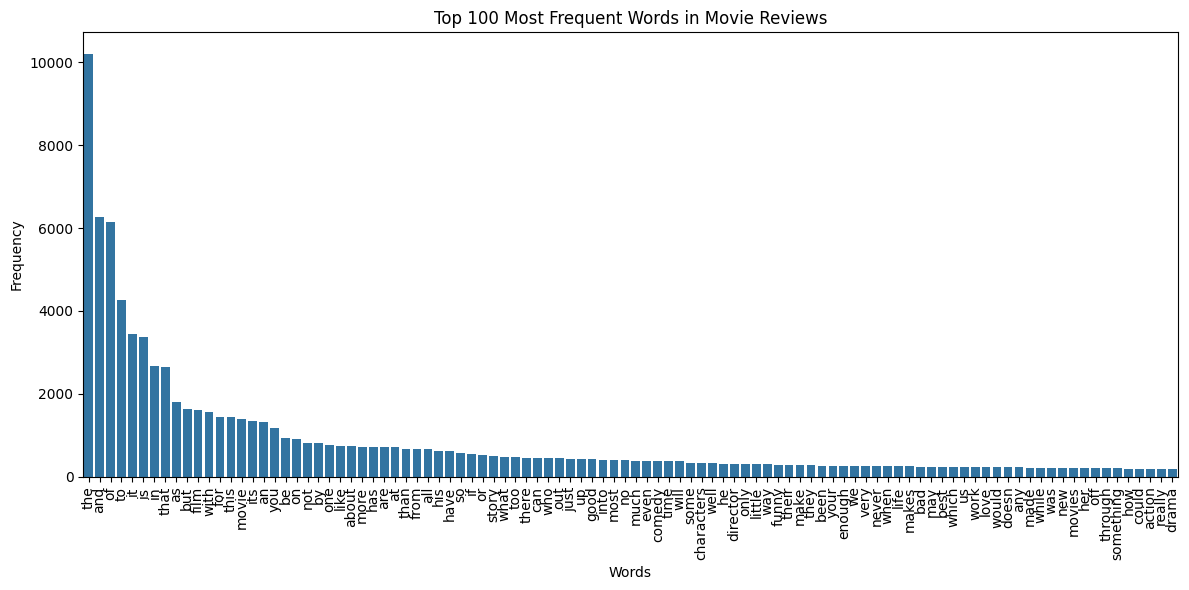

In [16]:
# get MFWs overall and plot
vectorizer = CountVectorizer(max_features=100)
all_vec = vectorizer.fit_transform(X)

# get the feature names and their counts
feature_names = vectorizer.get_feature_names_out()
feature_counts = all_vec.sum(axis=0).A1

# order the features by count
feature_counts, feature_names = zip(*sorted(zip(feature_counts, feature_names), reverse=True))

plt.figure(figsize=(12, 6))
sns.barplot(x=feature_names, y=feature_counts)
plt.xticks(rotation=90)
plt.title("Top 100 Most Frequent Words in Movie Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [18]:
# we want the 100 MFWs
vectorizer = CountVectorizer(max_features=100)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
# let's see what the features are
vectorizer.get_feature_names_out()

array(['about', 'action', 'all', 'an', 'and', 'any', 'are', 'as', 'at',
       'bad', 'be', 'been', 'best', 'but', 'by', 'can', 'characters',
       'comedy', 'could', 'director', 'doesn', 'enough', 'even', 'film',
       'for', 'from', 'funny', 'good', 'has', 'have', 'he', 'her', 'his',
       'how', 'if', 'in', 'into', 'is', 'it', 'its', 'just', 'life',
       'like', 'little', 'long', 'love', 'made', 'make', 'makes', 'may',
       'more', 'most', 'movie', 'movies', 'much', 'never', 'new', 'no',
       'not', 'of', 'off', 'on', 'one', 'only', 'or', 'out', 'really',
       'so', 'some', 'something', 'story', 'than', 'that', 'the', 'their',
       'there', 'they', 'this', 'time', 'to', 'too', 'two', 'up', 'us',
       'very', 'was', 'way', 'we', 'well', 'what', 'when', 'which',
       'while', 'who', 'will', 'with', 'work', 'would', 'you', 'your'],
      dtype=object)

In [19]:
# classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.63      0.58      0.61      1088
    positive       0.60      0.65      0.62      1045

    accuracy                           0.61      2133
   macro avg       0.61      0.61      0.61      2133
weighted avg       0.62      0.61      0.61      2133



__Create vectorizer object__

In [8]:
vectorizer = TfidfVectorizer(ngram_range = (1,2),     # unigrams and bigrams (1 word and 2 word units)
                             lowercase =  True,       # why use lowercase?
                             max_df = 0.95,           # remove very common words
                             min_df = 0.05,           # remove very rare words
                             max_features = 100)      # keep only top 100 features

This vectorizer is then used to turn all of our documents into a vector of numbers, instead of text.

In [9]:
# first we fit to the training data...
X_train_feats = vectorizer.fit_transform(X_train)

#... then do it for our test data
X_test_feats = vectorizer.transform(X_test)

# get feature names
feature_names = vectorizer.get_feature_names_out()

## Classifying and predicting

We now have to 'fit' the classifier to our data. This means that the classifier takes our data and finds correlations between features and labels.

These correlations are then the *model* that the classifier learns about our data. This model can then be used to predict the label for new, unseen data.

In [10]:
classifier = LogisticRegression(random_state=42).fit(X_train_feats, y_train)

Q: How do we use the classifier to make predictions?

In [11]:
y_pred = classifier.predict(X_test_feats)

Q: What are the predictions for the first 20 examples of the test data?

In [12]:
print(y_pred[:20])

['FAKE' 'FAKE' 'FAKE' 'FAKE' 'FAKE' 'FAKE' 'REAL' 'FAKE' 'REAL' 'FAKE'
 'REAL' 'REAL' 'REAL' 'FAKE' 'REAL' 'REAL' 'FAKE' 'REAL' 'REAL' 'REAL']


## Evaluate

We can also do some quick calculations, in order to assess just how well our model performs.

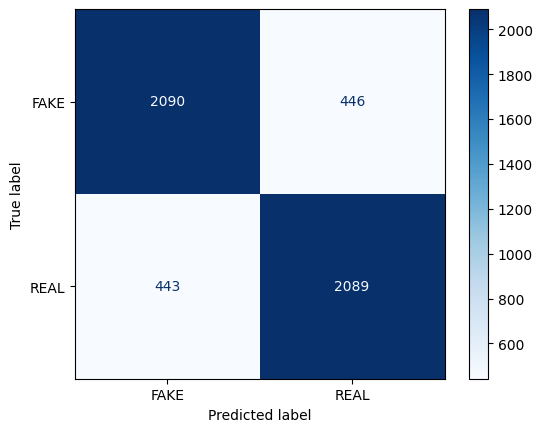

In [13]:
metrics.ConfusionMatrixDisplay.from_estimator(classifier,           # the classifier name
                                            X_train_feats,          # the training features
                                            y_train,                # the training labels
                                            cmap=plt.cm.Blues,      # make the colours prettier
                                            labels=["FAKE", "REAL"])# the labels in your data arranged alphabetically

__Calculating metrics__

```scikit-learn``` has a built-in set of tools which can be used to calculate these metrics, to get a better idea of how our model is performing.

In [14]:
classifier_metrics = metrics.classification_report(y_test, y_pred)
print(classifier_metrics)

              precision    recall  f1-score   support

        FAKE       0.84      0.81      0.82       628
        REAL       0.82      0.85      0.83       639

    accuracy                           0.83      1267
   macro avg       0.83      0.83      0.83      1267
weighted avg       0.83      0.83      0.83      1267



## Save models

It is also somewhat trivial to save models and reload them for later use. For that, we can use the library ```joblib```.

In [15]:
from joblib import dump, load
dump(classifier, "LR_classifier.joblib")
dump(vectorizer, "tfidf_vectorizer.joblib")

['tfidf_vectorizer.joblib']

We can restart the kernel for our notebook to see how that works:

In [16]:
from joblib import dump, load
loaded_clf = load("LR_classifier.joblib")
loaded_vect = load("tfidf_vectorizer.joblib")

In [17]:
sentence = "Hilary Clinton is a crook who eats babies!"

In [18]:
test_sentence = loaded_vect.transform([sentence])
loaded_clf.predict(test_sentence)

array(['FAKE'], dtype=object)

## Appendix - Interpreting a confusion matrix

Imagine that we are testing a classifier to see how well it can predict if someone has COVID:


```Accuracy => (TP+TN)/(TP+FP+FN+TN)```
- Ratio of correct classifications across all of the patients

```True Positive Rate => Recall  => Sensitivity => (TP / TP + FN)```
- The proportion of the positive class who were correctly classified
    - I.e sick people correctly identified as being sick

```Precision =>  (TP / TP + FP)```
- The ration of true positives to everyone predicted as positive
    - I.e. the proportion we identify as having COVID who actually do have it

```True negative rate => Specificity => (TN / TN + FP)```
- The proportion of the negative class who were correctly classified
    - I.e. healthy people who were correctly identified as being healthy

The following can also be calculated but are not featured on the confusion matrix above:

```False negative rate => (FN / TP + FN)```
- Proportion of the positive class who were incorrectly classified by the classifier
  - I.e. people predicted as healthy who are actually sick

```False positive rate = (FP / TN + FP) = 1 - Specificity```
- Proportion of the negative class who were incorrectly classified by the classifier
  - I.e. people predicted as sick who are actually healthy

```F1 => 2(P*R / P + R)```
- Harmonic mean of precision and recall, useful where both precision and recall are important